In [4]:
import torch
import torch.nn
import pandas as pd
import numpy
import torch.nn.functional
from torch.autograd import Variable
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
## Prepare Data set



In [5]:
temp_data=pd.read_csv(r'C:\Users\administrator\python_practice\current_out_all_clean_data.csv', low_memory=False)
temp_data['purpose']

y_temp=temp_data['total_rec_prncp']/temp_data['funded_amnt']

In [44]:
def clean_data(x):
    x.replace([numpy.inf], 0, inplace=True)
    x.replace([numpy.NAN], 0, inplace=True)

clean_data(y_temp)

# 'revol_util' 열의 모든 값을 문자열로 변환 후 '%' 기호를 제거하고 float로 변환
temp_data['revol_util'] = temp_data['revol_util'].astype(str).str.replace('%', '').astype(float)

temp_data.drop('id', axis=1, inplace=True)

select_feature = '''
annual_inc
inq_last_6mths
sub_grade
int_rate
installment
tot_cur_bal
avg_cur_bal
mo_sin_old_rev_tl_op
mo_sin_rcnt_rev_tl_op
mo_sin_rcnt_tl
mort_acc
num_il_tl
num_tl_120dpd_2m
num_tl_op_past_12m
revol_bal
total_bc_limit
dti
tot_hi_cred_lim
loan_amnt
term
emp_length
home_ownership
purpose
delinq_2yrs
revol_util
application_type
open_act_il
open_rv_24m
max_bal_bc
all_util
acc_open_past_24mths
num_op_rev_tl
num_rev_accts
num_tl_90g_dpd_24m
pct_tl_nvr_dlq
last_fico_range_high
verification_status
open_acc
pub_rec_bankruptcies
pub_rec
tax_liens
chargeoff_within_12_mths
pymnt_plan
fico_range_high
mths_since_last_delinq
total_acc
initial_list_status
collections_12_mths_ex_med
mths_since_last_major_derog
policy_code
annual_inc_joint
dti_joint
verification_status_joint
acc_now_delinq
open_acc_6m
open_il_12m
open_il_24m
mths_since_rcnt_il
total_bal_il
il_util
open_rv_12m
total_rev_hi_lim
total_cu_tl
inq_last_12m
bc_open_to_buy
bc_util
delinq_amnt
mo_sin_old_il_acct
mths_since_recent_bc
mths_since_recent_bc_dlq
mths_since_recent_inq
mths_since_recent_revol_delinq
num_accts_ever_120_pd
num_actv_bc_tl
num_actv_rev_tl
num_bc_sats
num_bc_tl
num_rev_tl_bal_gt_0
num_sats
num_tl_30dpd
percent_bc_gt_75
total_bal_ex_mort
total_il_high_credit_limit
revol_bal_joint
sec_app_fico_range_high
sec_app_inq_last_6mths
sec_app_mort_acc
sec_app_open_acc
sec_app_revol_util
sec_app_open_act_il
sec_app_num_rev_accts
sec_app_chargeoff_within_12_mths
sec_app_collections_12_mths_ex_med
'''
# 선택된 피처들로 데이터프레임 생성 (bar_ex_mort_year, bar_il_year, loan_year 제외)
select_feature = select_feature.strip().split('\n')
x_temp = temp_data[select_feature].reset_index(drop=True)

# 새로운 피처 추가 (선택된 피처 생성 후 추가)
x_temp['bar_ex_mort_year'] = x_temp['total_bal_ex_mort'] / x_temp['annual_inc']
x_temp['bar_il_year'] = x_temp['total_bal_il'] / x_temp['annual_inc']
x_temp['loan_year'] = x_temp['loan_amnt'] / x_temp['annual_inc']

# 결측값 및 무한대 값 처리
clean_data(x_temp)

# x_temp 데이터프레임 확인
print(x_temp.head())

KeyError: "['id'] not found in axis"

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error
import xgboost as xgb

# 데이터셋 분할 함수
def splitset(x, y):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
    x_train, x_valid, y_train, y_valid = train_test_split(x_train, y_train, test_size=0.25, random_state=42)
    return x_train.reset_index(drop=True), y_train.reset_index(drop=True), \
           x_valid.reset_index(drop=True), y_valid.reset_index(drop=True), \
           x_test.reset_index(drop=True), y_test.reset_index(drop=True)

# One-Hot Encoding 및 Standard Scaling 함수
def onehot_train_valid(x_train, x_valid, x_test):
    one = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    
    temp_data_train = x_train.select_dtypes(include='object')
    temp_data_valid = x_valid.select_dtypes(include='object')
    temp_data_test = x_test.select_dtypes(include='object')
    
    one.fit(temp_data_train)
    
    temp_x_train = one.transform(temp_data_train)
    temp_x_valid = one.transform(temp_data_valid)
    temp_x_test = one.transform(temp_data_test)
    
    columns = one.get_feature_names_out(temp_data_train.columns)
    
    temp_final_train = pd.DataFrame(temp_x_train, columns=columns)
    temp_final_valid = pd.DataFrame(temp_x_valid, columns=columns)
    temp_final_test = pd.DataFrame(temp_x_test, columns=columns)
    
    return temp_final_train, temp_final_valid, temp_final_test

def stsc_train_valid(x_train, x_valid, x_test):
    stdsc = StandardScaler()
    temp_x_train = x_train.select_dtypes(exclude='object')
    temp_x_valid = x_valid.select_dtypes(exclude='object')
    temp_x_test = x_test.select_dtypes(exclude='object')
    
    name = temp_x_train.columns
    stdsc.fit(temp_x_train)
    
    temp_x_train = stdsc.transform(temp_x_train)
    temp_x_valid = stdsc.transform(temp_x_valid)
    temp_x_test = stdsc.transform(temp_x_test)
    
    temp_x_train = pd.DataFrame(temp_x_train, columns=name)
    temp_x_valid = pd.DataFrame(temp_x_valid, columns=name)
    temp_x_test = pd.DataFrame(temp_x_test, columns=name)
    
    return temp_x_train, temp_x_valid, temp_x_test

# 데이터셋 로드 및 분할 (x_temp, y_temp는 기존에 정의된 데이터셋)
bx_train, y_train, bx_valid, y_valid, bx_test, y_test = splitset(x_temp, y_temp)

# One-Hot Encoding 및 Scaling 적용
one_train, one_valid, one_test = onehot_train_valid(bx_train, bx_valid, bx_test)
stsc_train, stsc_valid, stsc_test = stsc_train_valid(bx_train, bx_valid, bx_test)

# 최종 학습, 검증, 테스트 데이터셋 생성
x_train = pd.concat([stsc_train, one_train], axis=1)
x_valid = pd.concat([stsc_valid, one_valid], axis=1)
x_test = pd.concat([stsc_test, one_test], axis=1)

# 전처리된 데이터 사용
x_train = x_train.to_numpy()
y_train = y_train.to_numpy().ravel()
x_valid = x_valid.to_numpy()
y_valid = y_valid.to_numpy().ravel()
x_test = x_test.to_numpy()
y_test = y_test.to_numpy().ravel()

Fitting 2 folds for each of 100 candidates, totalling 200 fits


c:\Users\administrator\anaconda3\envs\moment\lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
10 fits failed out of a total of 200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\administrator\anaconda3\envs\moment\lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\administrator\anaconda3\envs\moment\lib\site-packages\xgboost\core.py", line 726, in inner_f
    return func(**kwargs)
  File "c:\Users\administrator\anaconda3\envs\moment\lib\site-packages\xgboost\sklearn.py", line 1108, in fit
    self._Booster = trai

Best parameters found:  {'tree_method': 'gpu_hist', 'random_state': 101, 'objective': 'reg:absoluteerror', 'n_estimators': 300, 'min_child_weight': 17, 'max_depth': 15, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 1.0}


c:\Users\administrator\anaconda3\envs\moment\lib\site-packages\xgboost\core.py:158: UserWarning: [19:41:52] WARNING: D:\bld\xgboost-split_1724807729805\work\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
c:\Users\administrator\anaconda3\envs\moment\lib\site-packages\xgboost\core.py:158: UserWarning: [19:41:52] WARNING: D:\bld\xgboost-split_1724807729805\work\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


Validation Set Performance:
RMSE: 0.2119307934253434
MSE: 0.044914661201895585
MAE: 0.09123661657984118
Test Set Performance:
RMSE: 0.2121990223714596
MSE: 0.04502842509540321
MAE: 0.09147593882480048


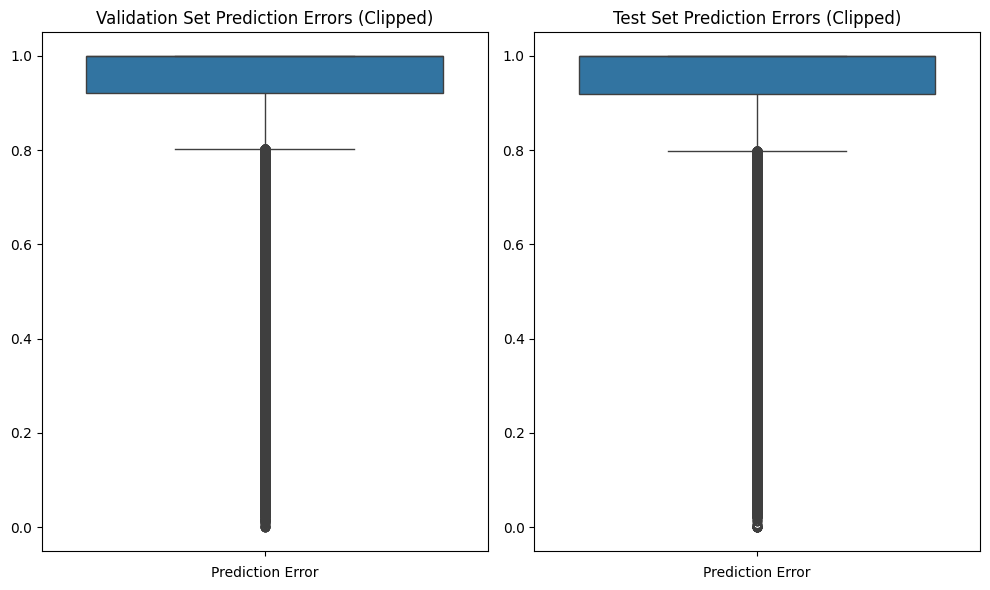

In [9]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# 하이퍼파라미터 설정
params = {
    'objective': ['reg:absoluteerror'],  # Mean Absolute Error로 설정
    'max_depth': np.arange(1, 16, 1),  # 더 깊은 트리를 시도
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],  # 더 작은 학습률 추가
    'n_estimators': [100, 300, 500],  # 중간 값 추가
    'colsample_bytree': [0.6, 0.8, 1.0],  # 각 트리에 대한 특성 샘플링 비율
    'gamma': [0, 0.1, 0.5, 1],  # 가지치기 결정에 영향을 미치는 감마 값
    'min_child_weight': np.arange(5, 25, 3),  # 리프 노드가 가져야 하는 최소 가중치 합
    'tree_method': ['gpu_hist'],  # GPU 사용을 위한 'gpu_hist' 설정
    'random_state': [101]
}

# XGBoost 모델 초기화
xgb_model = xgb.XGBRegressor()

# RandomizedSearchCV로 하이퍼파라미터 튜닝
random_search = RandomizedSearchCV(xgb_model, param_distributions=params, n_iter=100, cv=2, verbose=1, random_state=101, n_jobs=-1)
random_search.fit(x_train, y_train)

# 최적의 파라미터와 모델 출력
print("Best parameters found: ", random_search.best_params_)
best_model = random_search.best_estimator_

# 모델 성능 평가
y_pred_val = best_model.predict(x_valid)
y_pred_test = best_model.predict(x_test)

# 예측 값 클리핑 (0 미만은 0, 1 이상은 1로)
y_pred_val_clipped = np.clip(y_pred_val, 0, 1)
y_pred_test_clipped = np.clip(y_pred_test, 0, 1)

# Validation Set Performance
print("Validation Set Performance:")
val_rmse = np.sqrt(mean_squared_error(y_valid, y_pred_val_clipped))
val_mse = mean_squared_error(y_valid, y_pred_val_clipped)
val_mae = mean_absolute_error(y_valid, y_pred_val_clipped)

print(f"RMSE: {val_rmse}")
print(f"MSE: {val_mse}")
print(f"MAE: {val_mae}")

# Test Set Performance
print("Test Set Performance:")
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_clipped))
test_mse = mean_squared_error(y_test, y_pred_test_clipped)
test_mae = mean_absolute_error(y_test, y_pred_test_clipped)

print(f"RMSE: {test_rmse}")
print(f"MSE: {test_mse}")
print(f"MAE: {test_mae}")

# 박스플롯 그리기
plt.figure(figsize=(10, 6))

# Validation Set 박스플롯
plt.subplot(1, 2, 1)
sns.boxplot(y_pred_val_clipped)
plt.title('Validation Set Prediction Errors (Clipped)')
plt.xlabel('Prediction Error')

# Test Set 박스플롯
plt.subplot(1, 2, 2)
sns.boxplot(y_pred_test_clipped)
plt.title('Test Set Prediction Errors (Clipped)')
plt.xlabel('Prediction Error')

plt.tight_layout()
plt.show()


In [11]:
# 최적의 파라미터와 모델 출력
print("Best parameters found: ", random_search.best_params_)
best_model = random_search.best_estimator_

Best parameters found:  {'tree_method': 'gpu_hist', 'random_state': 101, 'objective': 'reg:absoluteerror', 'n_estimators': 300, 'min_child_weight': 17, 'max_depth': 15, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 1.0}


Number of features with positive importance: 34

Positive Feature Importance:
                               Feature  Importance
9                              pub_rec    0.910002
1                             int_rate    0.086655
3                            sub_grade    0.076381
0                                 term    0.069961
13                         open_il_24m    0.038789
29                  sec_app_revol_util    0.003927
5                           annual_inc    0.002817
2                          installment    0.002122
4                           emp_length    0.001399
7                              purpose    0.000857
20                 num_rev_tl_bal_gt_0    0.000673
26                     revol_bal_joint    0.000654
22                pub_rec_bankruptcies    0.000540
16                         avg_cur_bal    0.000425
8                      fico_range_high    0.000132
24                   total_bal_ex_mort    0.000107
17                mo_sin_old_rev_tl_op    0.000107
14  

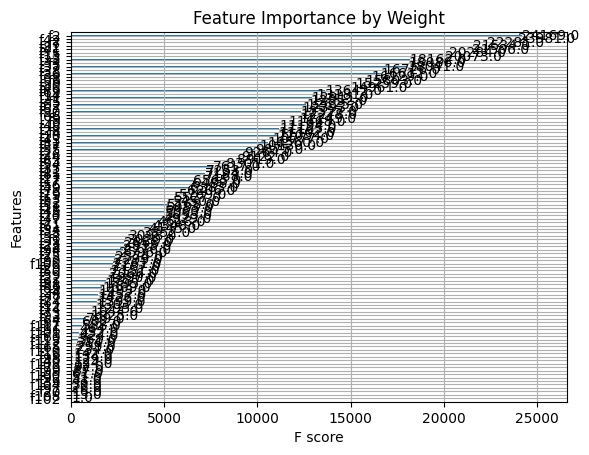

In [12]:
import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance  # permutation_importance 임포트
import xgboost as xgb
import matplotlib.pyplot as plt

# 전처리 단계에서 피처 이름을 저장해두기
feature_names = bx_train.columns  # 원래 DataFrame의 컬럼 이름을 저장

# Permutation Importance 계산
perm_importance = permutation_importance(best_model, x_valid, y_valid, n_repeats=10, random_state=101)

# 피처 중요도와 피처 이름 매핑
importance_values = perm_importance.importances_mean
feature_importance_dict = dict(zip(feature_names, importance_values))

# 양수 중요도와 피처 이름 매핑
positive_importance = {feature: importance for feature, importance in feature_importance_dict.items() if importance >= 0}

# 데이터프레임으로 변환
df_positive_importance = pd.DataFrame(list(positive_importance.items()), columns=['Feature', 'Importance']).sort_values(by='Importance', ascending=False)

# 양수 중요도 피처 수 계산
num_positive_features = len(positive_importance)

# 결과 출력
print(f"Number of features with positive importance: {num_positive_features}")

print("\nPositive Feature Importance:")
print(df_positive_importance)

# Feature importance plot (XGBoost 내장 기능 사용)
xgb.plot_importance(best_model, importance_type='weight', title='Feature Importance by Weight')
plt.show()

In [23]:
print("Best parameters found: ", random_search.best_params_)

Best parameters found:  {'tree_method': 'gpu_hist', 'random_state': 101, 'objective': 'reg:absoluteerror', 'n_estimators': 300, 'min_child_weight': 17, 'max_depth': 15, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 1.0}


                                   Feature   Weight
0                              1. int_rate  24169.0
1                           2. avg_cur_bal  23981.0
2                            3. annual_inc  22281.0
3                    4. sec_app_revol_util  21534.0
4                  5. acc_open_past_24mths  21506.0
..                                     ...      ...
81                         82. total_cu_tl     43.0
82          83. collections_12_mths_ex_med     16.0
83                     84. tot_hi_cred_lim      0.0
84                 85. sec_app_open_act_il      0.0
85  86. sec_app_collections_12_mths_ex_med      0.0

[86 rows x 2 columns]


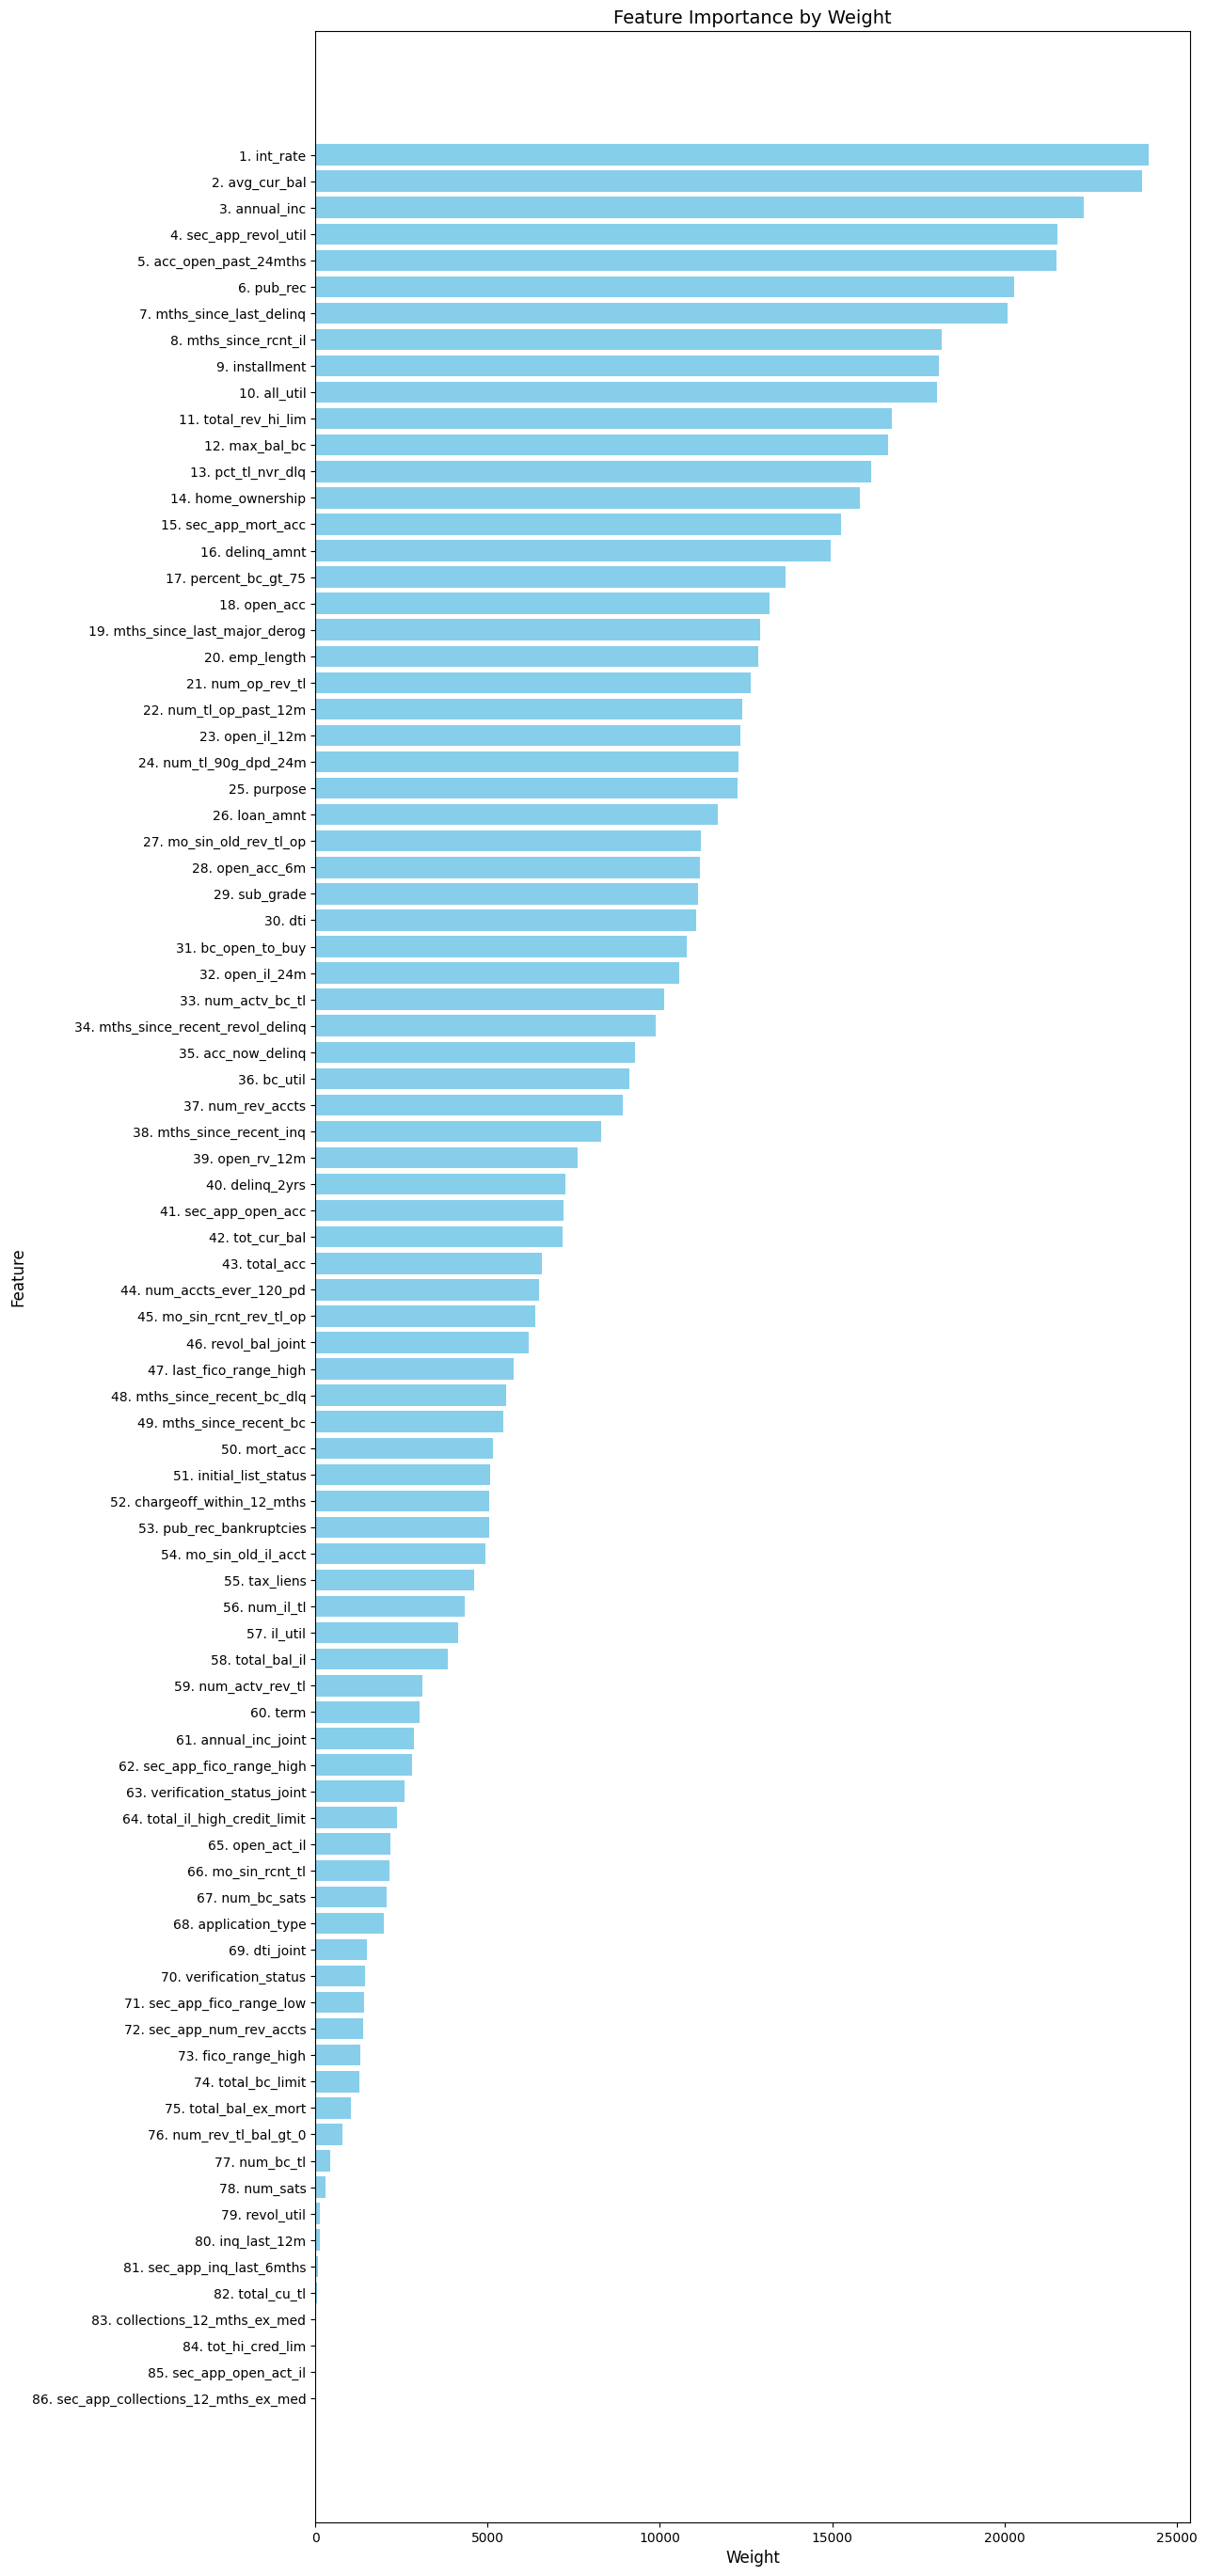

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb

# Feature importance 추출 (weight 기준)
booster = best_model.get_booster()
importance = booster.get_score(importance_type='weight')

# 모든 피처의 중요도를 0으로 초기화
importance_named = {feature: 0 for feature in select_feature}

# 피처 이름과 Weight를 매핑
for k, v in importance.items():
    if k.startswith('f') and k[1:].isdigit():
        index = int(k[1:])
        if index < len(select_feature):
            importance_named[select_feature[index]] = v
        else:
            print(f"Warning: Index {index} is out of range for select_feature.")
    else:
        importance_named[k] = v

# 피처 중요도를 리스트로 변환하여 정렬
sorted_importance = sorted(importance_named.items(), key=lambda item: item[1], reverse=True)

# 데이터를 DataFrame으로 변환 (피처 이름과 Weight 매핑)
df_importance = pd.DataFrame(sorted_importance, columns=['Feature', 'Weight'])

# 순서 번호 추가
df_importance['Feature'] = df_importance.index.map(lambda x: f"{x + 1}. {df_importance['Feature'][x]}")

# Feature와 Weight를 직접 비교해서 확인
print(df_importance)

# 시각화를 통해 비교
plt.figure(figsize=(12, len(df_importance) * 0.4))
plt.barh(df_importance['Feature'], df_importance['Weight'], color='skyblue')

plt.yticks(fontsize=10)
plt.xticks(fontsize=10)
plt.title('Feature Importance by Weight', fontsize=14)
plt.xlabel('Weight', fontsize=12)
plt.ylabel('Feature', fontsize=12)

plt.gca().invert_yaxis()  # 중요도가 높은 피처가 위쪽에 오도록 Y축 뒤집기
plt.show()

                            Feature   Weight
0                       1. int_rate  24169.0
1                    2. avg_cur_bal  23981.0
2                     3. annual_inc  22281.0
3             4. sec_app_revol_util  21534.0
4           5. acc_open_past_24mths  21506.0
5                        6. pub_rec  20284.0
6         7. mths_since_last_delinq  20073.0
7             8. mths_since_rcnt_il  18162.0
8                    9. installment  18086.0
9                      10. all_util  18041.0
10             11. total_rev_hi_lim  16726.0
11                   12. max_bal_bc  16612.0
12               13. pct_tl_nvr_dlq  16129.0
13               14. home_ownership  15803.0
14             15. sec_app_mort_acc  15259.0
15                  16. delinq_amnt  14961.0
16             17. percent_bc_gt_75  13642.0
17                     18. open_acc  13181.0
18  19. mths_since_last_major_derog  12911.0
19                   20. emp_length  12852.0
20                21. num_op_rev_tl  12625.0
21        

C:\Users\administrator\AppData\Local\Temp\2\ipykernel_8396\1508209694.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_importance_top30['Feature'] = df_importance_top30.index.map(lambda x: f"{x + 1}. {df_importance_top30['Feature'][x]}")


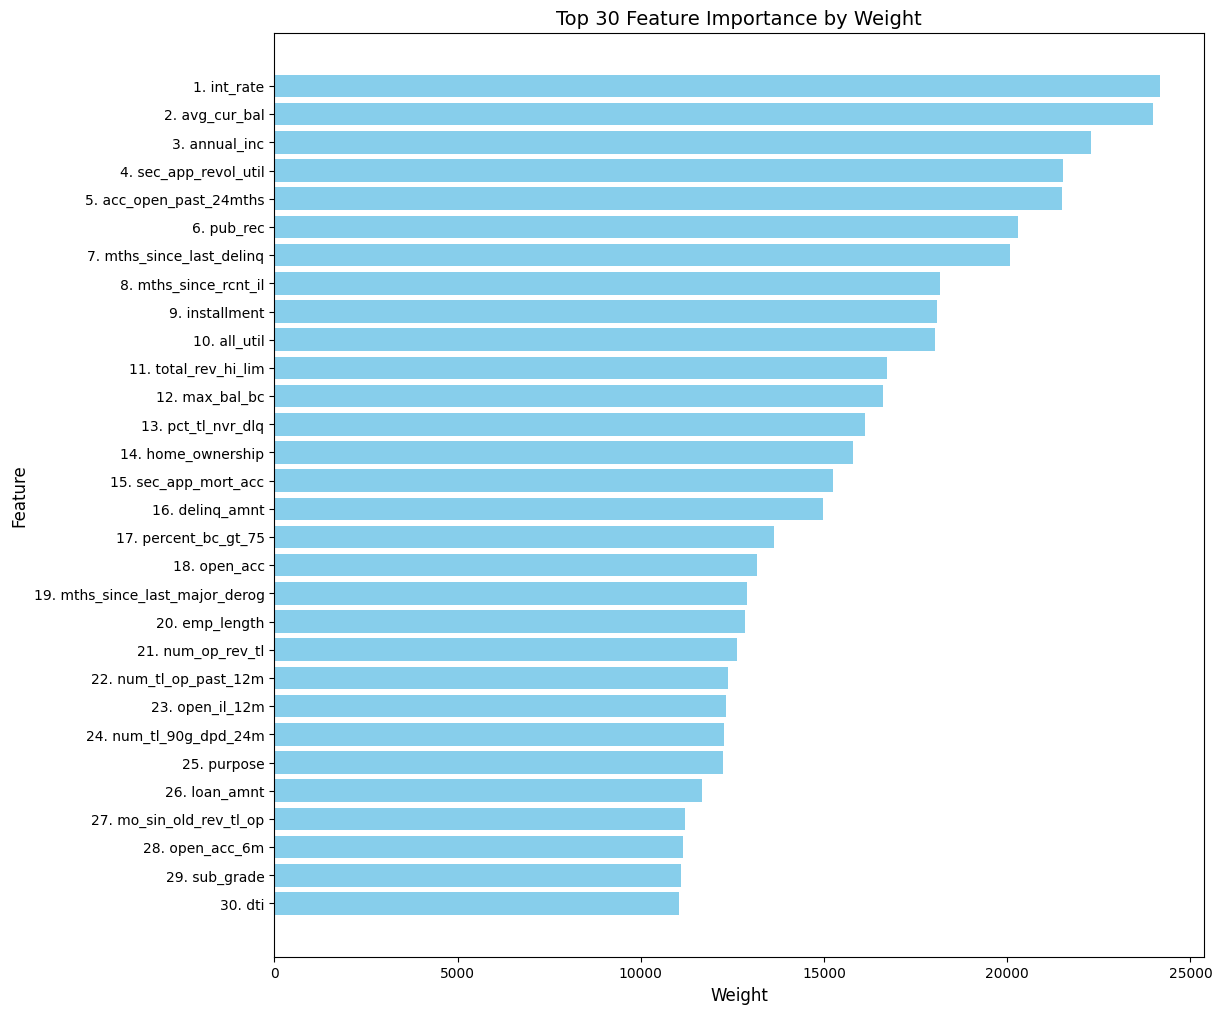

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb

# Feature importance 추출 (weight 기준)
booster = best_model.get_booster()
importance = booster.get_score(importance_type='weight')

# 모든 피처의 중요도를 0으로 초기화
importance_named = {feature: 0 for feature in select_feature}

# 피처 이름과 Weight를 매핑
for k, v in importance.items():
    if k.startswith('f') and k[1:].isdigit():
        index = int(k[1:])
        if index < len(select_feature):
            importance_named[select_feature[index]] = v
        else:
            print(f"Warning: Index {index} is out of range for select_feature.")
    else:
        importance_named[k] = v

# 피처 중요도를 리스트로 변환하여 정렬
sorted_importance = sorted(importance_named.items(), key=lambda item: item[1], reverse=True)

# 데이터를 DataFrame으로 변환 (피처 이름과 Weight 매핑)
df_importance = pd.DataFrame(sorted_importance, columns=['Feature', 'Weight'])

# 상위 30개의 피처만 선택
df_importance_top30 = df_importance.head(30)

# 순서 번호 추가
df_importance_top30['Feature'] = df_importance_top30.index.map(lambda x: f"{x + 1}. {df_importance_top30['Feature'][x]}")

# Feature와 Weight를 직접 비교해서 확인
print(df_importance_top30)

# 시각화를 통해 비교
plt.figure(figsize=(12, len(df_importance_top30) * 0.4))
plt.barh(df_importance_top30['Feature'], df_importance_top30['Weight'], color='skyblue')

plt.yticks(fontsize=10)
plt.xticks(fontsize=10)
plt.title('Top 30 Feature Importance by Weight', fontsize=14)
plt.xlabel('Weight', fontsize=12)
plt.ylabel('Feature', fontsize=12)

plt.gca().invert_yaxis()  # 중요도가 높은 피처가 위쪽에 오도록 Y축 뒤집기
plt.show()